In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
save_data=False

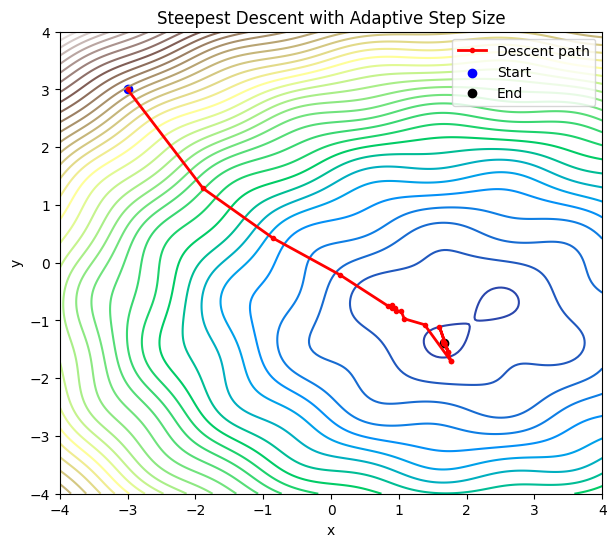

In [ ]:


# Define the function and its gradient
def f(x, y):
    return (x - 2)**2 + 2*(y + 1)**2 + np.sin(3*x)*np.sin(3*y)

def grad_f(x, y):
    dfdx = 2*(x - 2) + 3*np.cos(3*x)*np.sin(3*y)
    dfdy = 4*(y + 1) + 3*np.sin(3*x)*np.cos(3*y)
    return np.array([dfdx, dfdy])

# Steepest descent with adaptive step size
def steepest_descent_adaptive(f, grad_f, x0, alpha0=0.1, tol=1e-5, max_iter=200):
    x = x0.copy()
    alpha = alpha0
    path = [x.copy()]
    for i in range(max_iter):
        g = grad_f(*x)
        gnorm = np.linalg.norm(g)
        if gnorm < tol:
            break

        # tentative step
        new_x = x - alpha * g

        # adapt step size based on improvement
        if f(*new_x) < f(*x):
            x = new_x
            alpha *= 1.1  # increase step size if progress is good
        else:
            alpha *= 0.5  # reduce step size if overshoot

        path.append(x.copy())
    return np.array(path)

# Run the descent
x0 = np.array([-3.0, 3.0])
path = steepest_descent_adaptive(f, grad_f, x0)

# Visualization
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig, ax = plt.subplots(figsize=(7,6))
ax.contour(X, Y, Z, levels=40, cmap='terrain')
ax.plot(path[:,0], path[:,1], 'r.-', lw=2, label='Descent path')
ax.scatter([x0[0]], [x0[1]], color='blue', label='Start')
ax.scatter([path[-1,0]], [path[-1,1]], color='black', label='End')
ax.legend()
ax.set_title('Steepest Descent with Adaptive Step Size')
ax.set_xlabel('x')
ax.set_ylabel('y')
if save_data: fig.savefig('Pics/steepest_descent.pdf', transparent=True)
plt.show()


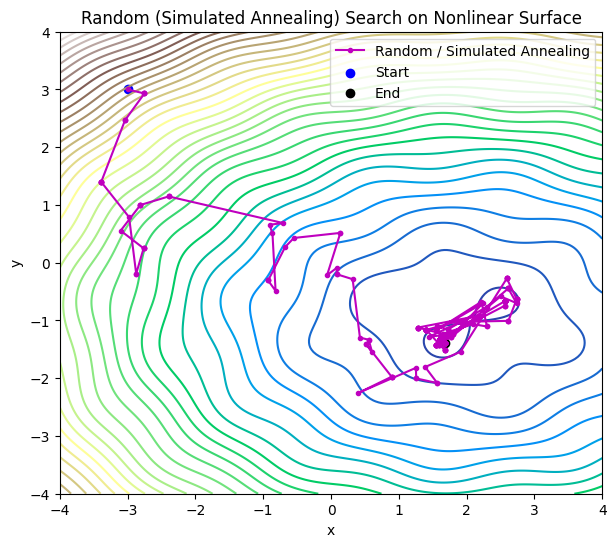

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Same surface as before
def f(x, y):
    return (x - 2)**2 + 2*(y + 1)**2 + np.sin(3*x)*np.sin(3*y)

# Random (simulated annealing) search
def random_search_sa(f, x0, T0=2.0, cooling=0.98, steps=500):
    x = np.array(x0)
    fx = f(*x)
    path = [x.copy()]
    T = T0
    for i in range(steps):
        # random proposal (Gaussian step)
        step = np.random.normal(scale=0.5, size=2)
        x_new = x + step
        fx_new = f(*x_new)
        delta = fx_new - fx
        
        # acceptance rule
        if delta < 0 or np.random.rand() < np.exp(-delta / T):
            x, fx = x_new, fx_new
        path.append(x.copy())
        
        # cooling schedule
        T *= cooling
    return np.array(path)

# Run the random algorithm
np.random.seed(42)
x0 = np.array([-3.0, 3.0])
path_sa = random_search_sa(f, x0)

# Compute surface
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Plot
fig, ax = plt.subplots(figsize=(7,6))
ax.contour(X, Y, Z, levels=40, cmap='terrain')
ax.plot(path_sa[:,0], path_sa[:,1], 'm.-', lw=1.5, label='Random / Simulated Annealing')
ax.scatter([x0[0]], [x0[1]], color='blue', label='Start')
ax.scatter([path_sa[-1,0]], [path_sa[-1,1]], color='black', label='End')
ax.set_title('Random (Simulated Annealing) Search on Nonlinear Surface')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()
if save_data: pass
fig.savefig('Pics/simulated annealing.pdf', transparent=True)
plt.show()
